In [1]:
import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd


In [2]:
from tqdm import tqdm

In [3]:
_file = "../../data/tng100_trees.npz"
with open(_file, 'rb') as fp:
    trees_data = np.load(fp)
    matches = trees_data['matches']
    bdmo = trees_data['bdmo']
    tdmo = trees_data['tdmo']
    bbar = trees_data['bbar']
    tbar = trees_data['tbar']
    


In [4]:
matches.shape, bdmo.shape, bbar.shape, tdmo.shape, tbar.shape

((153348,), (869229,), (153348,), (869229, 100), (153348, 100))

In [5]:
bbar.dtype, bdmo.dtype, tbar.dtype, tdmo.dtype

(dtype([('infall_snap', '<i4'), ('mpeak', '<f4'), ('mpeak_pre', '<f4'), ('is_err', '?'), ('vpeak', '<f4'), ('vpeak_pre', '<f4')]),
 dtype([('infall_snap', '<i4'), ('mpeak', '<f4'), ('mpeak_pre', '<f4'), ('is_err', '?'), ('vpeak', '<f4'), ('vpeak_pre', '<f4')]),
 dtype([('mdm', '<f4'), ('mvir', '<f4'), ('vmax', '<f4'), ('ok', '?'), ('is_sub', '?'), ('subfind_id', '<i8'), ('first_sub_idx', '<i8'), ('match', '<i8'), ('stellar_mass', '<f4')]),
 dtype([('mdm', '<f4'), ('mvir', '<f4'), ('vmax', '<f4'), ('ok', '?'), ('is_sub', '?'), ('subfind_id', '<i8'), ('first_sub_idx', '<i8'), ('match', '<i8')]))

# DMO

In [7]:
mask = (tdmo['ok'][:, -1]) & (tdmo['mdm'][:, -1] > 0) & (~bdmo['is_err'])
sum(mask) / len(mask), len(mask)

(np.float64(0.6139624885962157), 869229)

In [8]:
# percentage of bad trees that are not "OK"
# this flag captures all cases we care about
sum(mask), sum(tdmo['ok'][:, -1])

(np.int64(533674), np.int64(533674))

In [ ]:
# is_err does not flag any cases 
sum(~bdmo['is_err'])

np.int64(869229)

In [9]:
# mah
mvir = tdmo['mdm'][mask]
n_snaps = 100
n_haloes = mvir.shape[0]
mah = np.zeros((n_haloes, n_snaps)) * np.nan

for ii in tqdm(range(n_haloes)):

    mdm = mvir[ii, :]
    _mask = mdm == 0.0
    mdm[_mask] = np.nan

    # linearly interpolate nan values
    mdm = pd.Series(mdm)
    mdm = mdm.interpolate(method="linear", limit_direction="both", axis=0)
    mah[ii] = mdm.values


100%|██████████| 533674/533674 [00:31<00:00, 17131.00it/s]


In [10]:
# get mpeak
from multicam_tng.utils import get_mpeak_from_mah
mpeak_mah = get_mpeak_from_mah(np.log10(mah))
mpeak_mah.shape

(533674, 100)

In [12]:
# get a_{1/2}
import pandas as pd
metadata = pd.read_csv("../../data/tng300-1-table.csv") # this ist just metadata which sims share
t12 = np.zeros(n_haloes)
for ii in range(n_haloes):
    mah_ii = mpeak_mah[ii]
    idx = np.where(mpeak_mah[ii, :]> 0.5)[0][0]
    t12[ii] = metadata['Redshift'][idx]

In [13]:
a12 =  1 / (1 + t12)

In [15]:
# apply mkas universally
subfind_id = tdmo['subfind_id'][:, -1][mask]
vpeak_pre = bdmo['vpeak_pre'][mask]
vpeak = bdmo['vpeak'][mask]
mpeak_pre = bdmo['mpeak_pre'][mask]
mpeak = bdmo['mpeak'][mask]
is_sub = tdmo['is_sub'][:, -1][mask]
subfind_id.shape, vpeak_pre.shape, is_sub.shape, mpeak_mah.shape, a12.shape

((533674,), (533674,), (533674,), (533674, 100), (533674,))

In [16]:
out = {
    'subfind_id': subfind_id, 
    'vpeak_pre': vpeak_pre,
    'vpeak': vpeak,
    'mpeak_pre': mpeak_pre,
    'mpeak': mpeak,
    'mah': mah,
    'is_sub': is_sub,
    'mpeak_mah': mpeak_mah,
    'a12': a12,
}

with open("../../data/out-trees-tng100-dmo.npz", 'wb') as fp:
    np.savez(fp, **out)

# Baryons

In [17]:
mask = (tbar['ok'][:, -1]) & (tbar['mdm'][:, -1] > 0) & (~bbar['is_err'])
sum(mask) / len(mask), len(mask)

(np.float64(0.6614432532540365), 153348)

In [18]:
# mah
mvir = tbar['mdm'][mask]
n_snaps = 100
n_haloes = mvir.shape[0]
mah = np.zeros((n_haloes, n_snaps)) * np.nan

for ii in tqdm(range(n_haloes)):

    mdm = mvir[ii, :]
    _mask = mdm == 0.0
    mdm[_mask] = np.nan

    # linearly interpolate nan values
    mdm = pd.Series(mdm)
    mdm = mdm.interpolate(method="linear", limit_direction="both", axis=0)
    mah[ii] = mdm.values


  0%|          | 0/101431 [00:00<?, ?it/s]

100%|██████████| 101431/101431 [00:05<00:00, 17057.32it/s]


In [19]:
# get mpeak
from multicam_tng.utils import get_mpeak_from_mah
mpeak_mah = get_mpeak_from_mah(np.log10(mah))
mpeak_mah.shape

(101431, 100)

In [20]:
# get a_{1/2}
import pandas as pd
metadata = pd.read_csv("../../data/tng300-1-table.csv") # this ist just metadata which sims share
t12 = np.zeros(n_haloes)
for ii in range(n_haloes):
    mah_ii = mpeak_mah[ii]
    idx = np.where(mpeak_mah[ii, :]> 0.5)[0][0]
    t12[ii] = metadata['Redshift'][idx]

In [21]:
a12 =  1 / (1 + t12)

In [22]:
tbar['stellar_mass'].shape

(153348, 100)

In [23]:
# apply mkas universally
subfind_id = tbar['subfind_id'][:, -1][mask]
vpeak_pre = bbar['vpeak_pre'][mask]
vpeak = bbar['vpeak'][mask]
mpeak_pre = bbar['mpeak_pre'][mask]
mpeak = bbar['mpeak'][mask]
is_sub = tbar['is_sub'][:, -1][mask]
stellar_mass = tbar['stellar_mass'][:, -1][mask]
subfind_id.shape, vpeak_pre.shape, is_sub.shape, mpeak_mah.shape, a12.shape, stellar_mass.shape

((101431,), (101431,), (101431,), (101431, 100), (101431,), (101431,))

In [24]:
out = {
    'subfind_id': subfind_id, 
    'vpeak': vpeak,
    'mpeak_mah': mpeak_mah,
    'is_sub': is_sub,
    'a12': a12,
    'mpeak_pre': mpeak_pre,
    'mpeak': mpeak,
    'stellar_mass': stellar_mass,
}

with open("../../data/out-trees-tng100-bar.npz", 'wb') as fp:
    np.savez(fp, **out)

# Matches

In [27]:
mask_bar = mask = (tbar['ok'][:, -1]) & (tbar['mdm'][:, -1] > 0) & (~bbar['is_err'])
mask_dmo = (tdmo['ok'][:, -1]) & (tdmo['mdm'][:, -1] > 0) & (~bdmo['is_err'])


In [28]:
# repetitions
print(len(set([m.item() for m in matches])), len(matches))

#repetitions all come from "-1" placeholder element
print(sum(matches == -1) + len(set([m.item() for m in matches])) - 1) 

# indices range
matches.max(), bdmo.shape

143016 153348
153348


(np.int64(869228), (869229,))

In [29]:
# get inverse 
mask = matches != -1
index_bar = np.arange(len(bbar))
matches_dmo  = np.full(len(bdmo), fill_value=-1)
matches_dmo[matches[mask]] = index_bar[mask]
# mask2 = np.isin(np.arange(len(bdmo)), matches[mask1])
# assert sum(mask1) == sum(mask2)
# index_bar2 = index_bar[mask1]
# sort_mask = np.argsort(matches[mask1])


In [30]:
# sanity check
for ii, x in enumerate(matches):
    if x != -1:
        assert ii == matches_dmo[x]


In [31]:

out = {
    'matches_bar': matches[mask_bar],
    'matches_dmo': matches_dmo[mask_dmo],
}

with open("../../data/matches-trees-tng100.npz", 'wb') as fp:
    np.savez(fp, **out)

In [32]:
matches_dmo[mask_dmo].shape, matches[mask_bar].shape

((533674,), (101431,))

# How to get matched in order quantities


In [ ]:
with open("../../data/matches-trees-tng100.npz", 'rb') as fp:
    matches = np.load(fp)['matches_bar']

matches.shape

(101431,)

In [ ]:
# how to match baryons to dmo and get correct order.
mask = matches != -1
sort_mask = np.argsort(matches[mask]) # order corresponds to order in dmo table
x = bbar['vpeak'][mask][sort_mask]

In [ ]:
mask = matches_dmo != -1
y = bdmo['vpeak'][mask] # already ordered
y.shape

(143015,)

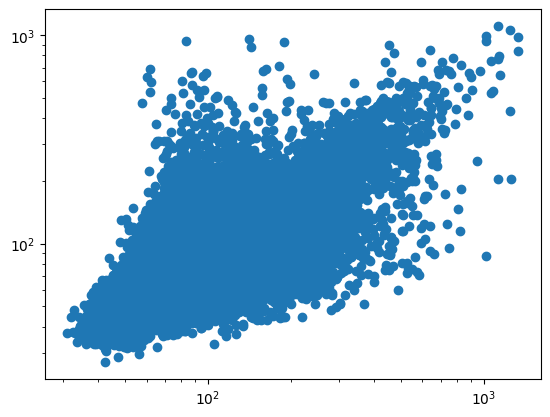

In [ ]:
plt.loglog(x, y, 'o')